<a href="https://colab.research.google.com/github/GAYATHRI-100/HACKTHON-INNOMATICS/blob/main/Task_2_Sentiment_Analysis_using_NLP_Pipeline_%26_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
print("Shape:", df.shape)

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
df = df.sample(20000, random_state=42)

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [9]:
df['clean_text'] = df['review'].apply(preprocess_text)

df[['review', 'clean_text']].head()

,review,clean_text
33553,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...
9427,Not many television shows appeal to quite as m...,many television show appeal quite many differe...
199,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...
12447,Jane Austen would definitely approve of this o...,jane austen would definitely approve one br br...
39489,Expectations were somewhat high for me when I ...,expectation somewhat high went see movie thoug...


In [10]:
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text'])

In [11]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [12]:
y = df['sentiment']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [13]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [14]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

y_pred_nb = nb.predict(X_test_bow)

In [15]:
dt = DecisionTreeClassifier()
dt.fit(X_train_bow, y_train)

y_pred_dt = dt.predict(X_test_bow)

In [16]:
def evaluate(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

In [17]:
print("🔹 Logistic Regression (TF-IDF)")
evaluate(y_test, y_pred_lr)

print("\n🔹 Naive Bayes (BoW)")
evaluate(y_test, y_pred_nb)

print("\n🔹 Decision Tree (BoW)")
evaluate(y_test, y_pred_dt)

🔹 Logistic Regression (TF-IDF)
Accuracy: 0.88425
Precision: 0.8846007583009554
Recall: 0.88425
F1 Score: 0.8842195414523035

🔹 Naive Bayes (BoW)
Accuracy: 0.847
Precision: 0.847019145478637
Recall: 0.847
F1 Score: 0.8469991967481926

🔹 Decision Tree (BoW)
Accuracy: 0.709
Precision: 0.7090703108199344
Recall: 0.709
F1 Score: 0.7089839215706863


In [18]:
!pip install wordcloud

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

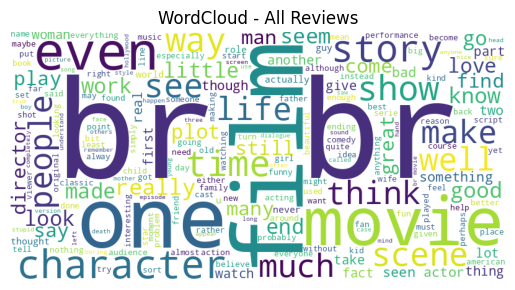

In [20]:
text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - All Reviews")
plt.show()

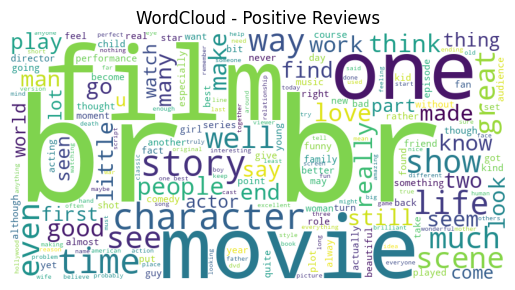

In [21]:
positive_text = " ".join(df[df['sentiment'] == 'positive']['clean_text'])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure()
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title("WordCloud - Positive Reviews")
plt.show()

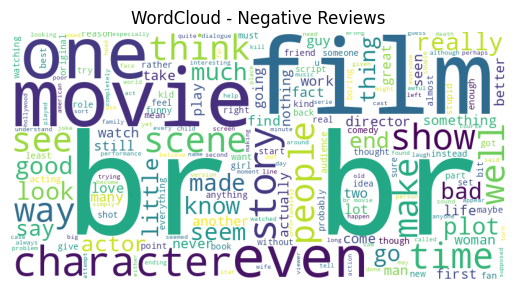

In [22]:
negative_text = " ".join(df[df['sentiment'] == 'negative']['clean_text'])

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure()
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title("WordCloud - Negative Reviews")
plt.show()

In [23]:
import pandas as pd
import numpy as np
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [24]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [25]:
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [26]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Reviews:")
print(df['review'].iloc[0])

Dataset Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, de

In [27]:
df = df.sample(20000, random_state=42)

In [28]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercasing
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation & special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [29]:
df['clean_text'] = df['review'].apply(preprocess_text)

df[['review', 'clean_text']].head()

,review,clean_text
33553,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...
9427,Not many television shows appeal to quite as m...,many television show appeal quite many differe...
199,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...
12447,Jane Austen would definitely approve of this o...,jane austen would definitely approve one br br...
39489,Expectations were somewhat high for me when I ...,expectation somewhat high went see movie thoug...


In [30]:
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text'])

In [31]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [32]:
y = df['sentiment']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [33]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [34]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

y_pred_nb = nb.predict(X_test_bow)

In [35]:
dt = DecisionTreeClassifier()
dt.fit(X_train_bow, y_train)

y_pred_dt = dt.predict(X_test_bow)

In [36]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

In [37]:
evaluate_model("Logistic Regression (TF-IDF)", y_test, y_pred_lr)
evaluate_model("Naive Bayes (BoW)", y_test, y_pred_nb)
evaluate_model("Decision Tree (BoW)", y_test, y_pred_dt)


Logistic Regression (TF-IDF)
------------------------------
Accuracy : 0.88425
Precision: 0.8846007583009554
Recall   : 0.88425
F1 Score : 0.8842195414523035

Naive Bayes (BoW)
------------------------------
Accuracy : 0.84725
Precision: 0.8472718247226978
Recall   : 0.84725
F1 Score : 0.8472489975750551

Decision Tree (BoW)
------------------------------
Accuracy : 0.70925
Precision: 0.7092516206309717
Recall   : 0.70925
F1 Score : 0.7092472196529049


In [38]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.88425,0.884601,0.88425,0.884220
1,Naive Bayes,0.84725,0.847272,0.84725,0.847249
2,Decision Tree,0.70925,0.709252,0.70925,0.709247


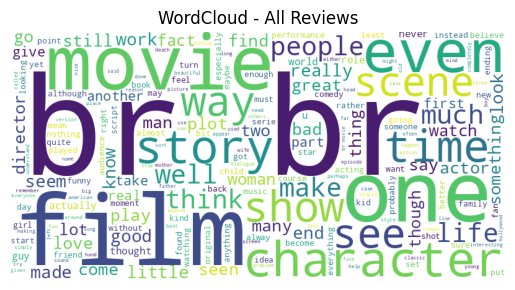

In [39]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud - All Reviews")
plt.show()